# CNN model on oversampled Data

In [ ]:
# =========================
# GOOGLE DRIVE MOUNT
# =========================
from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/chess_project/"

# =========================
# IMPORTS
# =========================
import pandas as pd
import numpy as np

from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

import tensorflow as tf

# =========================
# LOAD DATA
# =========================
df = pd.read_parquet(base_path + "chess_scalar.parquet")

print("Scalar shape:", df.shape)

X_tensor = np.load(base_path + "chess_tensor.npy", mmap_mode='r')

# mmap_mode='r'
# prevents full tensor loading into RAM

print("Tensor shape:", X_tensor.shape)

# =========================
# ORIGINAL CLASS COUNTS
# =========================
print("\n========== ORIGINAL CLASS COUNTS ==========\n")
print(df["label"].value_counts())

# =========================
# CREATE INDEX COLUMN
# =========================
df = df.reset_index(drop=True)

df["idx"] = np.arange(len(df))

# =========================
# OVERSAMPLING USING INDICES
# =========================
max_count = df["label"].value_counts().max()

balanced_indices = []

for label_name in df["label"].unique():

    class_indices = df[df["label"] == label_name]["idx"].values

    oversampled_indices = resample(
        class_indices,
        replace=True,
        n_samples=max_count,
        random_state=42
    )

    balanced_indices.extend(oversampled_indices)

# shuffle indices
balanced_indices = np.array(balanced_indices)

np.random.shuffle(balanced_indices)

# =========================
# BUILD BALANCED DATASET
# =========================
df_balanced = df.iloc[balanced_indices].reset_index(drop=True)

# tensor fetched lazily
X_tensor_balanced = X_tensor[balanced_indices]

# =========================
# NEW CLASS COUNTS
# =========================
print("\n========== BALANCED CLASS COUNTS ==========\n")
print(df_balanced["label"].value_counts())

# =========================
# LABEL ENCODING
# =========================
le = LabelEncoder()

y_encoded = le.fit_transform(df_balanced["label"])

y = tf.keras.utils.to_categorical(y_encoded)

print("\nClasses:", le.classes_)

# =========================
# REMOVE LEAKAGE FEATURES
# =========================
leak_cols = [
    "label",
    "delta",
    "eval",
    "piece_moved",
    "is_capture",
    "gives_check",
    "idx"
]

X_scalar = df_balanced.drop(columns=leak_cols).values

print("\nScalar input shape:", X_scalar.shape)

# =========================
# TRAIN TEST SPLIT
# =========================
X_tensor_train, X_tensor_test, \
X_scalar_train, X_scalar_test, \
y_train, y_test = train_test_split(
    X_tensor_balanced,
    X_scalar,
    y,
    test_size=0.2,
    random_state=42,
    stratify=np.argmax(y, axis=1)
)

print("\nTrain shape:")
print(X_tensor_train.shape)

print("\nTest shape:")
print(X_tensor_test.shape)

# =========================
# SCALE SCALAR FEATURES
# =========================
scaler = StandardScaler()

X_scalar_train = scaler.fit_transform(X_scalar_train)

X_scalar_test = scaler.transform(X_scalar_test)

# =========================
# FINAL INFO
# =========================
print("\nDone.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Scalar shape: (337981, 21)
Tensor shape: (337981, 12, 8, 8)

========== ORIGINAL CLASS COUNTS ==========

label
good          221151
excellent      57825
inaccuracy     28194
mistake        22817
blunder         7994
Name: count, dtype: int64

========== BALANCED CLASS COUNTS ==========

label
mistake       221151
blunder       221151
excellent     221151
good          221151
inaccuracy    221151
Name: count, dtype: int64

Classes: ['blunder' 'excellent' 'good' 'inaccuracy' 'mistake']

Scalar input shape: (1105755, 15)

Train shape:
(884604, 12, 8, 8)

Test shape:
(221151, 12, 8, 8)

Done.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 12, 8, 8)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 12, 8, 32) │      2,336 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 12, 8, 32) │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 6, 4, 32)  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 6, 4, 64)  │     18,496 │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 6, 4, 64)  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 15)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 1536)      │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      1,024 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    196,736 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 192)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     24,704 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 5)         │        645 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 244,581 (955.39 KB)

 Trainable params: 244,261 (954.14 KB)

 Non-trainable params: 320 (1.25 KB)


Starting training...

Epoch 1/100
22116/22116 ━━━━━━━━━━━━━━━━━━━━ 114s 5ms/step - accuracy: 0.5102 - loss: 1.1449 - val_accuracy: 0.5641 - val_loss: 1.0585
Epoch 2/100
22116/22116 ━━━━━━━━━━━━━━━━━━━━ 95s 4ms/step - accuracy: 0.5863 - loss: 1.0409 - val_accuracy: 0.6096 - val_loss: 0.9956
Epoch 3/100
22116/22116 ━━━━━━━━━━━━━━━━━━━━ 96s 4ms/step - accuracy: 0.6165 - loss: 1.0005 - val_accuracy: 0.6396 - val_loss: 0.9595
Epoch 4/100
22116/22116 ━━━━━━━━━━━━━━━━━━━━ 95s 4ms/step - accuracy: 0.6378 - loss: 0.9778 - val_accuracy: 0.6527 - val_loss: 0.9461
Epoch 5/100
22116/22116 ━━━━━━━━━━━━━━━━━━━━ 96s 4ms/step - accuracy: 0.6524 - loss: 0.9612 - val_accuracy: 0.6675 - val_loss: 0.9279
Epoch 6/100
22116/22116 ━━━━━━━━━━━━━━━━━━━━ 96s 4ms/step - accuracy: 0.6634 - loss: 0.9487 - val_accuracy: 0.6767 - val_loss: 0.9203
Epoch 7/100
22116/22116 ━━━━━━━━━━━━━━━━━━━━ 142s 4ms/step - accuracy: 0.6713 - loss: 0.9377 - val_accuracy: 0.6853 - val_loss: 0.9073
Epoch 8/100
22116/22116 ━━━━━━━━━━━━━

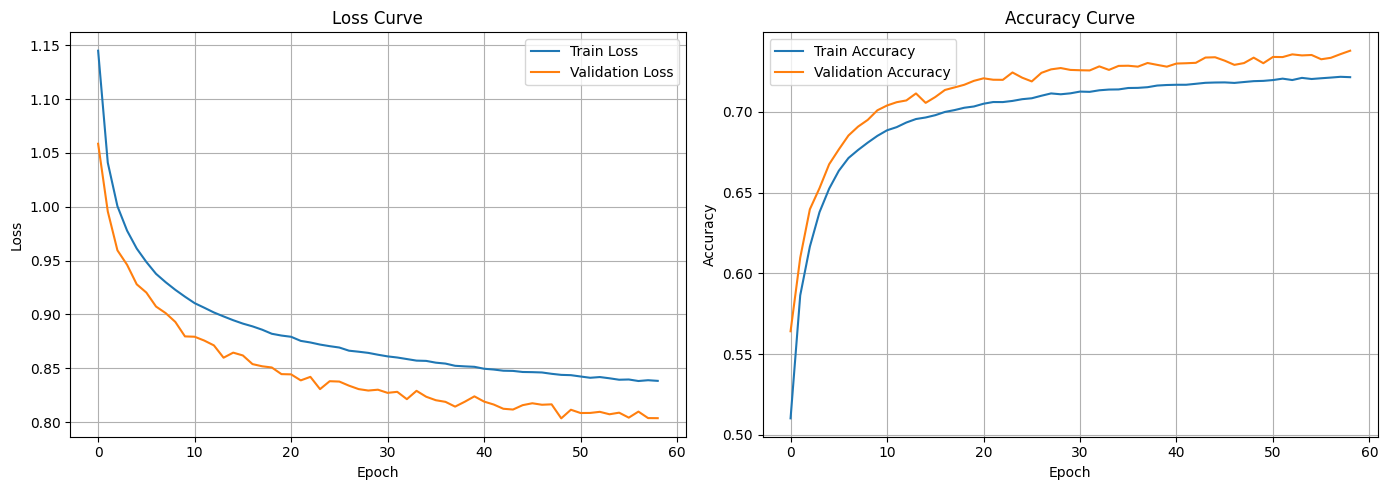


Evaluating model...


Test Accuracy: 73.44%


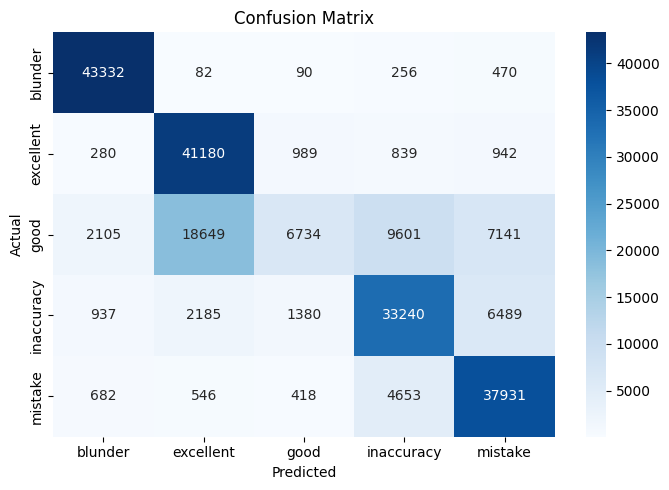


Classification Report:

              precision    recall  f1-score   support

     blunder       0.92      0.98      0.95     44230
   excellent       0.66      0.93      0.77     44230
        good       0.70      0.15      0.25     44230
  inaccuracy       0.68      0.75      0.72     44231
     mistake       0.72      0.86      0.78     44230

    accuracy                           0.73    221151
   macro avg       0.73      0.73      0.69    221151
weighted avg       0.73      0.73      0.69    221151



In [ ]:
# ==========================================================
# IMPORTS FOR MODEL TRAINING
# ==========================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

# ==========================================================
# OPTIONAL MEMORY OPTIMIZATION
# ==========================================================
# reduces RAM usage significantly

X_tensor_train = X_tensor_train.astype(np.float16)
X_tensor_test = X_tensor_test.astype(np.float16)

X_scalar_train = X_scalar_train.astype(np.float32)
X_scalar_test = X_scalar_test.astype(np.float32)

# ==========================================================
# BUILD CNN + SCALAR MODEL
# ==========================================================
def build_chess_model(
    tensor_shape,
    scalar_dim,
    num_classes
):

    # ======================================================
    # TENSOR INPUT BRANCH (CNN)
    # ======================================================
    tensor_input = layers.Input(shape=tensor_shape)

    x = layers.Conv2D(
        filters=32,
        kernel_size=(3,3),
        padding='same',
        activation='swish'
    )(tensor_input)

    x = layers.BatchNormalization()(x)

    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Conv2D(
        filters=64,
        kernel_size=(3,3),
        padding='same',
        activation='swish'
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.Flatten()(x)

    x = layers.Dense(
        128,
        activation='swish',
        kernel_regularizer=regularizers.l2(0.001)
    )(x)

    x = layers.Dropout(0.3)(x)

    # ======================================================
    # SCALAR INPUT BRANCH
    # ======================================================
    scalar_input = layers.Input(shape=(scalar_dim,))

    y = layers.Dense(
        64,
        activation='swish'
    )(scalar_input)

    y = layers.BatchNormalization()(y)

    y = layers.Dropout(0.2)(y)

    # ======================================================
    # MERGE BOTH BRANCHES
    # ======================================================
    combined = layers.concatenate([x, y])

    z = layers.Dense(
        128,
        activation='swish'
    )(combined)

    z = layers.Dropout(0.3)(z)

    output = layers.Dense(
        num_classes,
        activation='softmax'
    )(z)

    # ======================================================
    # CREATE MODEL
    # ======================================================
    model = models.Model(
        inputs=[tensor_input, scalar_input],
        outputs=output
    )

    # ======================================================
    # OPTIMIZER
    # ======================================================
    optimizer = tf.keras.optimizers.Adam(
        learning_rate=0.0005,
        clipnorm=1.0
    )

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# ==========================================================
# BUILD MODEL
# ==========================================================
model = build_chess_model(
    tensor_shape=X_tensor_train.shape[1:],
    scalar_dim=X_scalar_train.shape[1],
    num_classes=len(le.classes_)
)

# ==========================================================
# MODEL SUMMARY
# ==========================================================
model.summary()

# ==========================================================
# EARLY STOPPING
# ==========================================================
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# ==========================================================
# TRAIN MODEL
# ==========================================================
print("\nStarting training...\n")

history = model.fit(
    [X_tensor_train, X_scalar_train],
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,   # lower batch size prevents RAM crash
    callbacks=[early_stop],
    verbose=1
)

# ==========================================================
# PLOT TRAINING CURVES
# ==========================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))

# LOSS PLOT
ax1.plot(history.history['loss'], label='Train Loss')
ax1.plot(history.history['val_loss'], label='Validation Loss')

ax1.set_title('Loss Curve')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# ACCURACY PLOT
ax2.plot(history.history['accuracy'], label='Train Accuracy')
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy')

ax2.set_title('Accuracy Curve')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# ==========================================================
# EVALUATE MODEL
# ==========================================================
print("\nEvaluating model...\n")

test_loss, test_acc = model.evaluate(
    [X_tensor_test, X_scalar_test],
    y_test,
    verbose=0
)

print(f"\nTest Accuracy: {test_acc*100:.2f}%")

# ==========================================================
# PREDICTIONS
# ==========================================================
y_pred = np.argmax(
    model.predict(
        [X_tensor_test, X_scalar_test],
        verbose=0
    ),
    axis=1
)

y_true = np.argmax(y_test, axis=1)

class_names = [str(cls) for cls in le.classes_]

# ==========================================================
# CONFUSION MATRIX
# ==========================================================
plt.figure(figsize=(7,5))

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================
print("\nClassification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

## complete model summary


========== COMPLETE MODEL SUMMARY ==========



Model: "Chess_CNN_Scalar_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━
┃ Layer (type)                       ┃ Output Shape                   ┃              Param # ┃ Connected to        
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━
│ Tensor_Input (InputLayer)          │ (None, 8, 8, 12)               │                    0 │ -                   
├────────────────────────────────────┼────────────────────────────────┼──────────────────────┼─────────────────────
│ Conv2D_1 (Conv2D)                  │ (None, 8, 8, 32)               │                3,488 │ Tensor_Input[0][0]  
├────────────────────────────────────┼────────────────────────────────┼──────────────────────┼─────────────────────
│ BatchNorm_1 (BatchNormalization)   │ (None, 8, 8, 32)               │                  128 │ Conv2D_1[0][0]      
├────────────────────────────────────┼────────────────────────────────┼──────────────────────┼─────────────────────
│ MaxPool_1 (MaxPooling2D)           │ (None, 4, 4, 32)               │                    0 │ BatchNorm_1[0][0]   
├────────────────────────────────────┼────────────────────────────────┼──────────────────────┼─────────────────────
│ Conv2D_2 (Conv2D)                  │ (None, 4, 4, 64)               │               18,496 │ MaxPool_1[0][0]     
├────────────────────────────────────┼────────────────────────────────┼──────────────────────┼─────────────────────
│ BatchNorm_2 (BatchNormalization)   │ (None, 4, 4, 64)               │                  256 │ Conv2D_2[0][0]      
├────────────────────────────────────┼────────────────────────────────┼──────────────────────┼─────────────────────
│ Scalar_Input (InputLayer)          │ (None, 15)                     │                    0 │ -                   
├────────────────────────────────────┼────────────────────────────────┼──────────────────────┼─────────────────────
│ Flatten (Flatten)                  │ (None, 1024)                   │                    0 │ BatchNorm_2[0][0]   
├────────────────────────────────────┼────────────────────────────────┼──────────────────────┼─────────────────────
│ Scalar_Dense (Dense)               │ (None, 64)                     │                1,024 │ Scalar_Input[0][0]  
├────────────────────────────────────┼────────────────────────────────┼──────────────────────┼─────────────────────
│ Tensor_Dense (Dense)               │ (None, 128)                    │              131,200 │ Flatten[0][0]       
├────────────────────────────────────┼────────────────────────────────┼──────────────────────┼─────────────────────
│ Scalar_BatchNorm                   │ (None, 64)                     │                  256 │ Scalar_Dense[0][0]  
│ (BatchNormalization)               │                                │                      │                     
├────────────────────────────────────┼────────────────────────────────┼──────────────────────┼─────────────────────
│ Tensor_Dropout (Dropout)           │ (None, 128)                    │                    0 │ Tensor_Dense[0][0]  
├────────────────────────────────────┼────────────────────────────────┼──────────────────────┼─────────────────────
│ Scalar_Dropout (Dropout)           │ (None, 64)                     │                    0 │ Scalar_BatchNorm[0][
├────────────────────────────────────┼────────────────────────────────┼──────────────────────┼─────────────────────
│ Concatenate (Concatenate)          │ (None, 192)                    │                    0 │ Tensor_Dropout[0][0]
│                                    │                                │                      │ Scalar_Dropout[0][0]
├────────────────────────────────────┼────────────────────────────────┼──────────────────────┼─────────────────────
│ Combined_Dense (Dense)             │ (None, 128)                    │               24,704 │ Concatenate[0][0]   
├────────────────────────────────────┼──────────────────

 Total params: 180,197 (703.89 KB)

 Trainable params: 179,877 (702.64 KB)

 Non-trainable params: 320 (1.25 KB)


========== MODEL INPUTS ==========

Input 1
Name  : Tensor_Input
Shape : (None, 8, 8, 12)

Input 2
Name  : Scalar_Input
Shape : (None, 15)


========== MODEL OUTPUT ==========

Output Shape : (None, 5)

========== LAYER DETAILS ==========


Layer 1
Name         : Tensor_Input
Type         : InputLayer
Output Shape : (None, 8, 8, 12)
Parameters   : 0
Trainable    : True

Layer 2
Name         : Conv2D_1
Type         : Conv2D
Input Shape  : (None, 8, 8, 12)
Output Shape : (None, 8, 8, 32)
Parameters   : 3488
Trainable    : True

Layer 3
Name         : BatchNorm_1
Type         : BatchNormalization
Input Shape  : (None, 8, 8, 32)
Output Shape : (None, 8, 8, 32)
Parameters   : 128
Trainable    : True

Layer 4
Name         : MaxPool_1
Type         : MaxPooling2D
Input Shape  : (None, 8, 8, 32)
Output Shape : (None, 4, 4, 32)
Parameters   : 0
Trainable    : True

Layer 5
Name         : Conv2D_2
Type         : Conv2D
Input Shape  : (None, 4, 4, 32)
Output Shape : (None, 4, 4, 64)
Parameters   

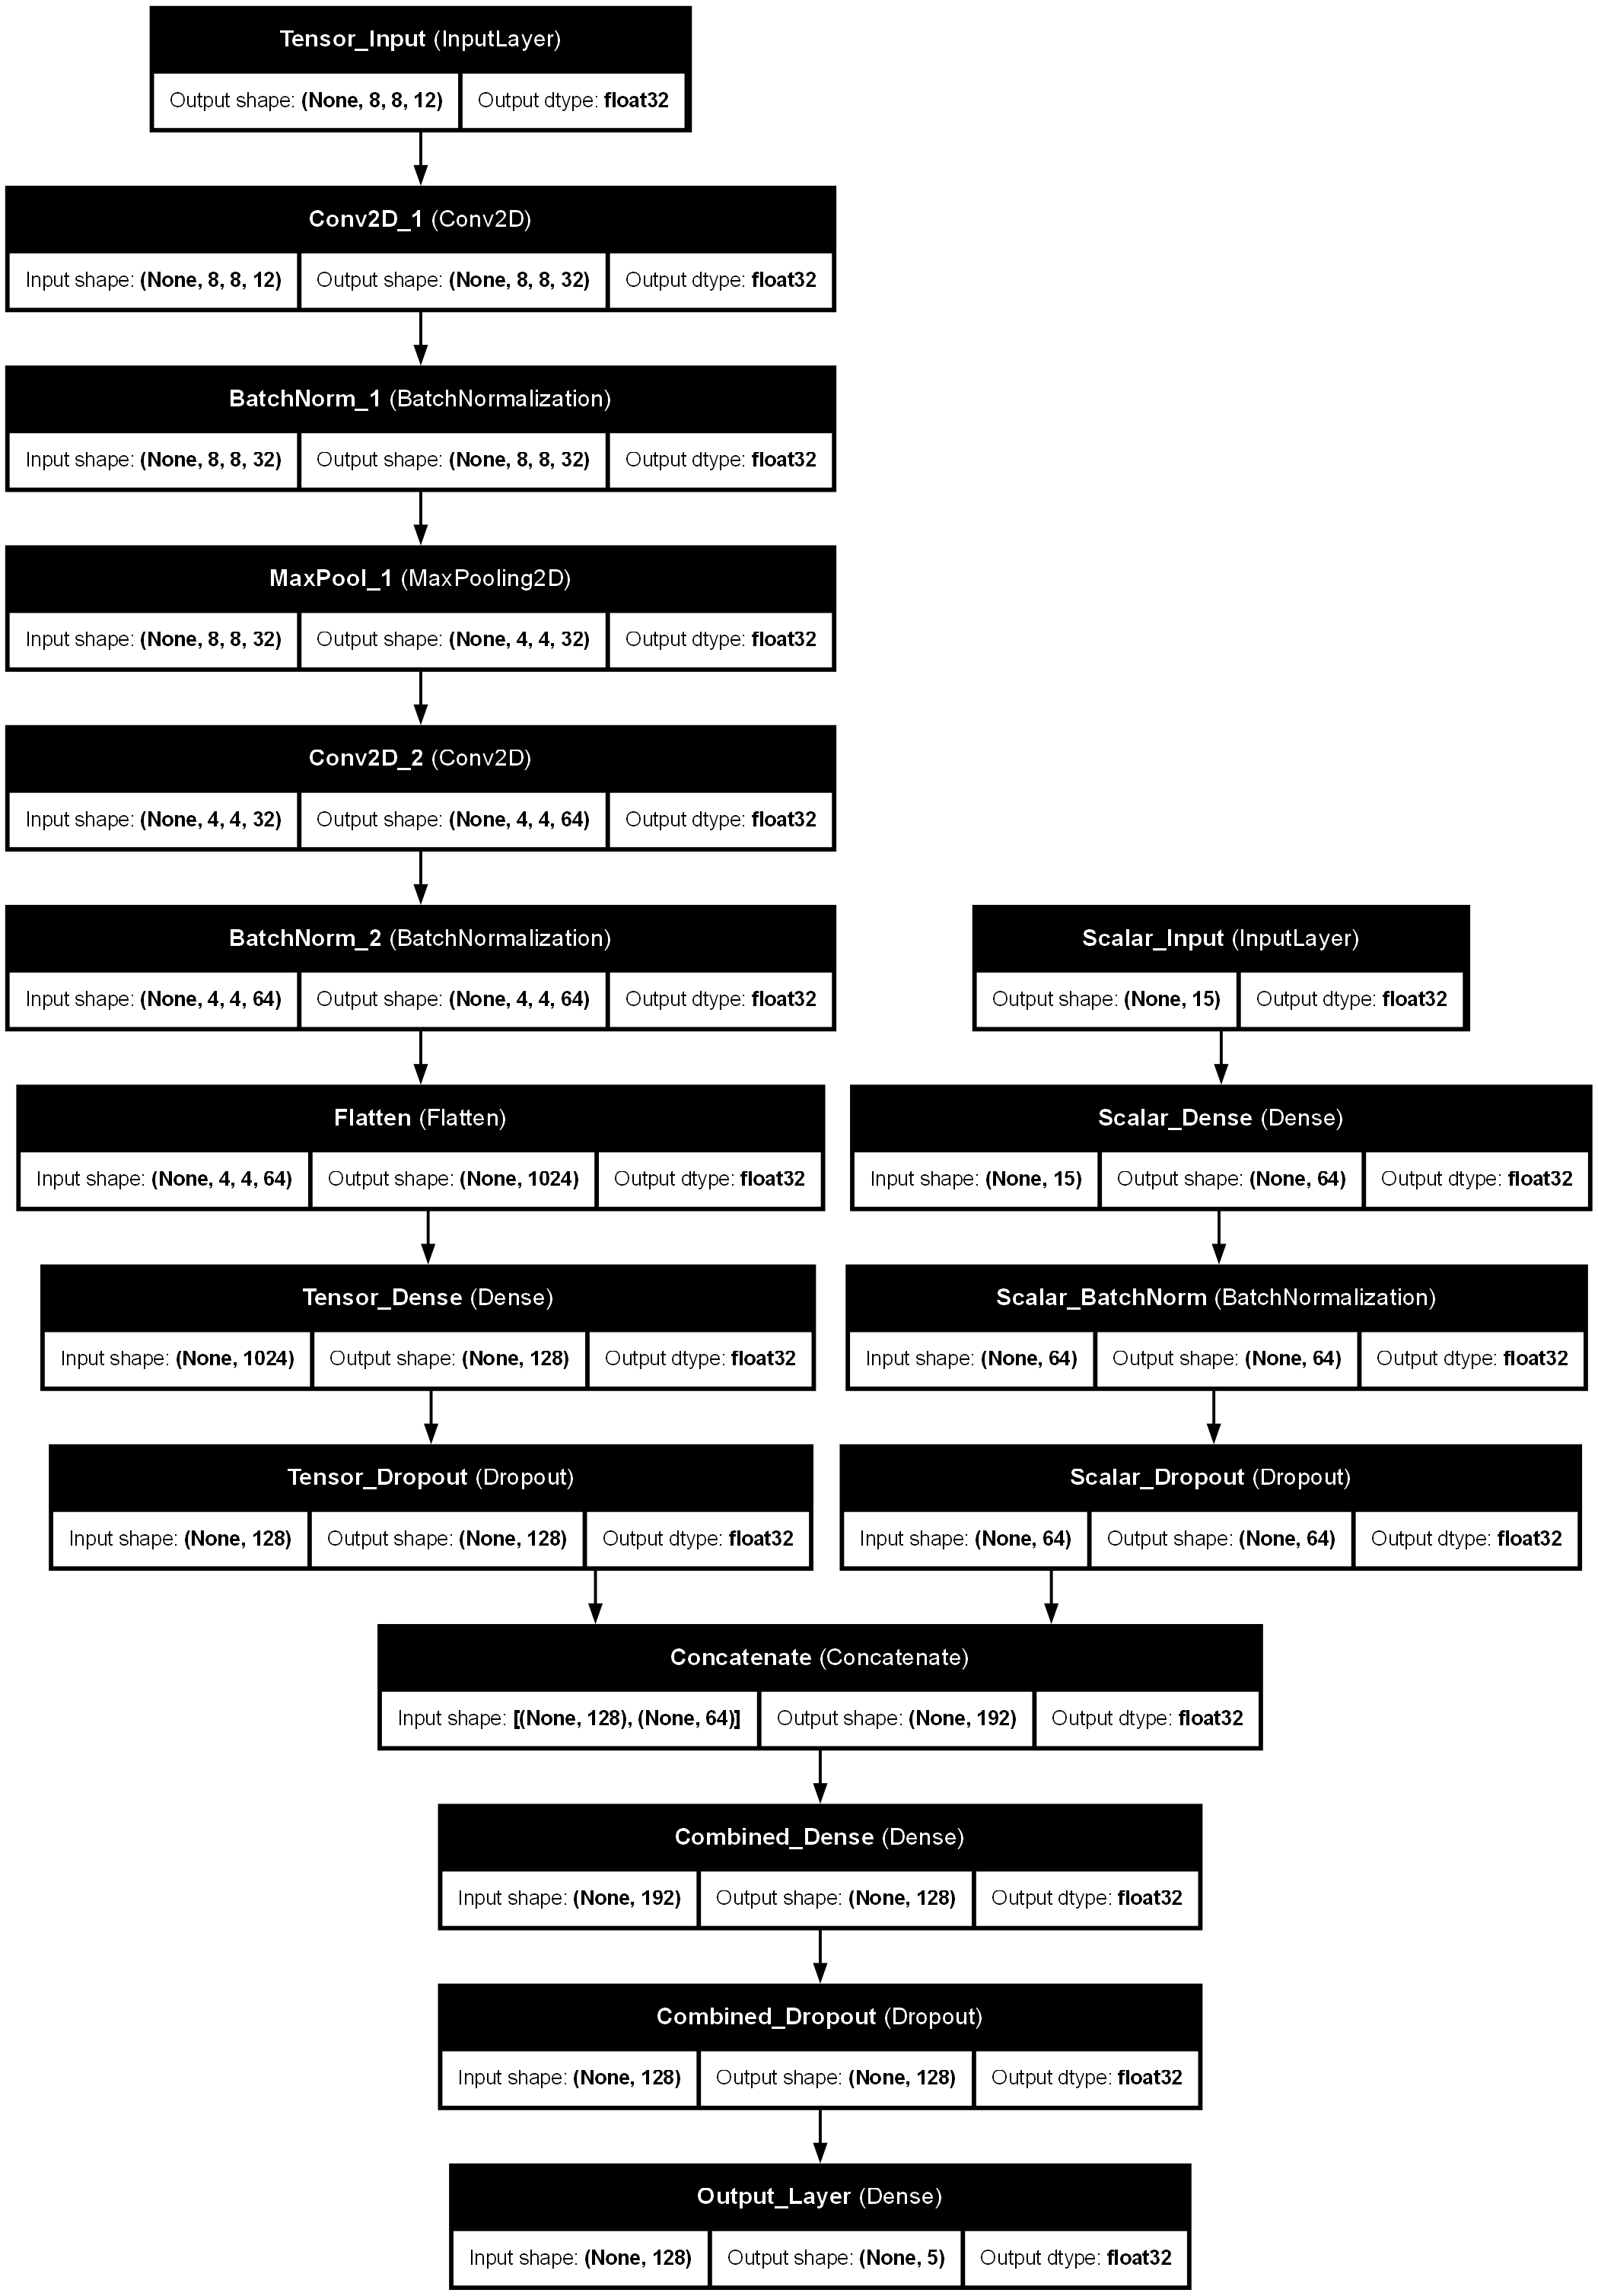

In [1]:
# ==========================================================
# IMPORTS
# ==========================================================

import numpy as np
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import regularizers

from tensorflow.keras.utils import plot_model

from IPython.display import Image
from IPython.display import display

# ==========================================================
# ASSUMED INPUT DETAILS
# ==========================================================

# tensor shape = (8, 8, 12)
tensor_shape = (8, 8, 12)

# scalar feature count
scalar_dim = 15

# number of output classes
num_classes = 5

# ==========================================================
# BUILD CNN + SCALAR MODEL
# ==========================================================

def build_chess_model(
    tensor_shape,
    scalar_dim,
    num_classes
):

    # ======================================================
    # TENSOR INPUT BRANCH
    # ======================================================

    tensor_input = layers.Input(
        shape=tensor_shape,
        name="Tensor_Input"
    )

    x = layers.Conv2D(
        filters=32,
        kernel_size=(3,3),
        padding='same',
        activation='swish',
        name="Conv2D_1"
    )(tensor_input)

    x = layers.BatchNormalization(
        name="BatchNorm_1"
    )(x)

    x = layers.MaxPooling2D(
        (2,2),
        name="MaxPool_1"
    )(x)

    x = layers.Conv2D(
        filters=64,
        kernel_size=(3,3),
        padding='same',
        activation='swish',
        name="Conv2D_2"
    )(x)

    x = layers.BatchNormalization(
        name="BatchNorm_2"
    )(x)

    x = layers.Flatten(
        name="Flatten"
    )(x)

    x = layers.Dense(
        128,
        activation='swish',
        kernel_regularizer=regularizers.l2(0.001),
        name="Tensor_Dense"
    )(x)

    x = layers.Dropout(
        0.3,
        name="Tensor_Dropout"
    )(x)

    # ======================================================
    # SCALAR INPUT BRANCH
    # ======================================================

    scalar_input = layers.Input(
        shape=(scalar_dim,),
        name="Scalar_Input"
    )

    y = layers.Dense(
        64,
        activation='swish',
        name="Scalar_Dense"
    )(scalar_input)

    y = layers.BatchNormalization(
        name="Scalar_BatchNorm"
    )(y)

    y = layers.Dropout(
        0.2,
        name="Scalar_Dropout"
    )(y)

    # ======================================================
    # MERGE BRANCHES
    # ======================================================

    combined = layers.concatenate(
        [x, y],
        name="Concatenate"
    )

    z = layers.Dense(
        128,
        activation='swish',
        name="Combined_Dense"
    )(combined)

    z = layers.Dropout(
        0.3,
        name="Combined_Dropout"
    )(z)

    output = layers.Dense(
        num_classes,
        activation='softmax',
        name="Output_Layer"
    )(z)

    # ======================================================
    # CREATE MODEL
    # ======================================================

    model = models.Model(
        inputs=[tensor_input, scalar_input],
        outputs=output,
        name="Chess_CNN_Scalar_Model"
    )

    # ======================================================
    # COMPILE MODEL
    # ======================================================

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=0.0005,
        clipnorm=1.0
    )

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# ==========================================================
# BUILD MODEL
# ==========================================================

model = build_chess_model(
    tensor_shape=tensor_shape,
    scalar_dim=scalar_dim,
    num_classes=num_classes
)

# ==========================================================
# COMPLETE MODEL SUMMARY
# ==========================================================

print("\n========== COMPLETE MODEL SUMMARY ==========\n")

model.summary(
    line_length=140,
    expand_nested=True,
    show_trainable=True
)

# ==========================================================
# MODEL INPUTS / OUTPUTS
# ==========================================================

print("\n========== MODEL INPUTS ==========\n")

for i, inp in enumerate(model.inputs):

    print(f"Input {i+1}")

    print(f"Name  : {inp.name}")

    print(f"Shape : {inp.shape}")

    print()

print("\n========== MODEL OUTPUT ==========\n")

print(f"Output Shape : {model.output.shape}")

# ==========================================================
# LAYER-WISE DETAILS
# ==========================================================

print("\n========== LAYER DETAILS ==========\n")

for i, layer in enumerate(model.layers):

    print(f"\nLayer {i+1}")

    print(f"Name         : {layer.name}")

    print(f"Type         : {layer.__class__.__name__}")

    try:
        print(f"Input Shape  : {layer.input.shape}")
    except:
        pass

    try:
        print(f"Output Shape : {layer.output.shape}")
    except:
        pass

    print(f"Parameters   : {layer.count_params()}")

    print(f"Trainable    : {layer.trainable}")

# ==========================================================
# PARAMETER SUMMARY
# ==========================================================

print("\n========== PARAMETER SUMMARY ==========\n")

print(f"Total Parameters      : {model.count_params():,}")

trainable_params = np.sum(
    [np.prod(v.shape) for v in model.trainable_weights]
)

non_trainable_params = np.sum(
    [np.prod(v.shape) for v in model.non_trainable_weights]
)

print(f"Trainable Parameters  : {trainable_params:,}")

print(f"Non-Trainable Params  : {non_trainable_params:,}")

# ==========================================================
# SAVE MODEL ARCHITECTURE IMAGE
# ==========================================================

plot_model(
    model,
    to_file="cnn_scalar_model_architecture.png",
    show_shapes=True,
    show_dtype=True,
    show_layer_names=True,
    expand_nested=True,
    dpi=140
)

print("\nModel architecture image saved as:")
print("cnn_scalar_model_architecture.png")

# ==========================================================
# DISPLAY MODEL IMAGE
# ==========================================================

display(
    Image(
        filename="cnn_scalar_model_architecture.png"
    )
)